# 04 — Predictive maintenance (models.md §3)

Probability that a machine fails within the next **48 engine hours**, the likely component, and
the SHAP factors behind it. XGBoost on hourly per-machine features built from the full 90-day
synthetic run.

* Features exactly as models.md §3 (v1), anomaly features from `ml.inference.anomaly`, engine
  hours rebuilt per shift as in `ml/01_anomaly.ipynb` but cut at failures from `maintenance_log`.
* Label: 1 if a `maintenance_log` failure occurs within the next 48 engine hours. Hours between a
  failure and its repair are dropped, and so are censored hours at the end of the run.
* Time split days 1–70 / 71–80 / 81–90. **The test period holds only 2 failures**, too few to
  evaluate, so the main evaluation is **grouped time-based cross-validation by failure** (below).
* `anomaly_label`, `anomaly_type` and `data/output/truth/` are **never** features. One cell in the
  diagnosis section reads `truth/failures.csv` (drift window length) to explain misses. Nothing from it
  flows into a model.

Feature code lives in `ml/inference/maintenance.py`, so notebook and backend compute the same thing.

In [1]:
import json, sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn, xgboost
from sklearn.metrics import average_precision_score
from xgboost import XGBClassifier

ROOT = Path.cwd().resolve()
while not (ROOT / "CLAUDE.md").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import ml.inference.maintenance as M

DATA = ROOT / "data" / "output"
ART = ROOT / "ml" / "artifacts" / "maintenance"
ART.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
START = pd.Timestamp("2026-06-01", tz="UTC")
XGB_PARAMS = dict(n_estimators=400, max_depth=5, learning_rate=0.05, subsample=0.8,
                  colsample_bytree=0.8, min_child_weight=3, gamma=0.1, eval_metric="aucpr",
                  random_state=RANDOM_STATE)
ALARM, HIGH = 0.5, 0.6                 # recall threshold, lead-time threshold (models.md §3)
TARGET_RECALL, TARGET_LEAD_H = 0.75, 12.0
NORMAL_H = 250                         # rows > 250 engine h before a failure fit the z-scales
pd.set_option("display.width", 160)

## 1 — Data (explicit columns, no truth files)

In [2]:
import ml.inference.anomaly as A
cols = list(dict.fromkeys(M.TELEMETRY_COLUMNS + A.INPUT_COLUMNS))   # explicit; never anomaly_label/type
tel = pd.read_parquet(DATA / "telemetry.parquet", columns=cols)
tel = tel.sort_values(["machine_id", "ts"], kind="stable").reset_index(drop=True)
machines = pd.read_csv(DATA / "machines.csv")
shifts = pd.read_csv(DATA / "shifts.csv")
mlog = pd.read_csv(DATA / "maintenance_log.csv")
assert not {"anomaly_label", "anomaly_type"} & set(tel.columns)
failures = M._failures(mlog)
print(tel.shape, "|", len(failures), "failures:", failures.component.value_counts().to_dict())

(652228, 17) | 25 failures: {'hydraulics': 11, 'cooling': 4, 'electrical': 4, 'engine': 4, 'undercarriage': 2}


### Engine hours
A shift adds its full length (cut at a logged failure), anchored so the last shift ends at
`machines.total_engine_hours`. Check: the rebuilt engine hours at each failure must match the
`engine_hours_at_event` logged in `maintenance_log`.

In [3]:
she = M.shift_engine_hours(shifts, machines, mlog)
x = failures.merge(she, on="machine_id")
x = x[(x.failure_ts >= x.start_time) & (x.failure_ts < x.start_time + pd.Timedelta(hours=12))]
x = x.sort_values("start_time").groupby("failure_ts").tail(1)
err = (x.eh_start + (x.failure_ts - x.start_time).dt.total_seconds() / 3600 - x.engine_hours_at_event).abs()
print(f"{len(x)} failures, max |rebuilt - logged| = {err.max():.3f} engine h")
assert len(x) == 25 and err.max() < 0.1

25 failures, max |rebuilt - logged| = 0.050 engine h


## 2 — Hourly features (models.md §3)
Anomaly detector (model 1) on every minute, then one row per machine × engine-hour bin: the
prediction is made at the bin's last telemetry minute, and every window trails it.

* 24 h / 72 h (engine hours) minute-weighted mean and least-squares slope (units per engine hour) of
  coolant, oil pressure, hydraulic oil temperature, hourly std of hydraulic pressure, vibration and battery.
  Sensor glitches are replaced by the previous reading first (model 1's rule).
* `anomaly_count24` = `machine_fault` events (runs of fault minutes) starting in the last 24 h;
  `anomaly_score_mean24` = mean minute score. Glitches don't count.
* `fault_code_count24` / `fault_code_count7d` = fault-code episodes (runs of one code); 7d is calendar days.
* `hours_since_service`, `service_ratio`, `high_load_hours_since_service` (load > 80 %) since the
  last logged scheduled service; one-hot `machine_type`; `age_years`.

In [4]:
mscores = M.score_minutes(tel, machines.set_index("machine_id").machine_type)
print(mscores.kind.value_counts().to_dict())
feats = M.build_hourly_features(tel, mscores, shifts, machines, mlog)
lab = M.label_hours(feats, mlog, machines.set_index("machine_id").total_engine_hours)
d = pd.concat([feats, lab], axis=1)
print(f"{len(d):,} machine-hours; dropped {(~d.keep).sum()} (failure->repair or censored at the end)")
d = d[d.keep].reset_index(drop=True)
d["machine_type"] = d.machine_type.astype(str)
day = (d.ts - START).dt.days + 1
d["split"] = np.select([day <= 70, day <= 80], ["train", "val"], "test")
assert not {"anomaly_label", "anomaly_type"} & set(M.FEATURE_COLUMNS)
d[M.SPEC_FEATURES].describe().T.round(2)

{'normal': 651785, 'machine_fault': 272, 'sensor_glitch': 171}


11,347 machine-hours; dropped 569 (failure->repair or censored at the end)


,count,mean,std,min,25%,50%,75%,max
hours_since_service,10778.0,259.81,142.51,0.00,143.11,264.28,382.38,506.88
service_ratio,10778.0,0.52,0.29,0.00,0.29,0.53,0.76,1.01
coolant_temp_c_mean24,10778.0,87.40,1.67,78.62,86.50,87.21,87.94,99.35
coolant_temp_c_slope24,10754.0,0.01,0.20,-2.36,-0.09,0.00,0.09,4.18
coolant_temp_c_mean72,10778.0,87.40,1.34,78.62,86.74,87.27,87.72,96.34
coolant_temp_c_slope72,10754.0,0.01,0.15,-2.36,-0.02,0.00,0.02,4.18
oil_pressure_kpa_mean24,10778.0,316.27,17.27,153.27,308.39,318.43,326.97,376.74
oil_pressure_kpa_slope24,10754.0,0.11,2.42,-24.47,-1.06,-0.01,1.07,63.80
oil_pressure_kpa_mean72,10778.0,316.12,13.00,153.27,311.12,317.98,324.08,376.74
oil_pressure_kpa_slope72,10754.0,0.13,1.84,-24.47,-0.23,0.01,0.26,63.80


## 3 — Time split: too few test failures

In [5]:
split_tab = pd.DataFrame({
    "hours": d.groupby("split").size(),
    "positive_hours": d.groupby("split").label.sum(),
    "failures": d[d.label == 1].groupby("split").next_failure_ts.nunique(),
}).loc[["train", "val", "test"]]
split_tab

,hours,positive_hours,failures
split,,,
train,8801,1025,23
val,1244,102,4
test,733,67,2


**Days 81–90 hold 2 failures (M08 undercarriage, M04 electrical)**, so test PR-AUC, recall and
lead time would each rest on 1–2 events. Validation has 4, one of which starts in train. That is too few
to judge the model, so the main evaluation is **grouped, time-based, forward-chaining
cross-validation by failure**:

* Fold boundaries fall on days with **no open 48-h pre-failure window** (Jul 2, Jul 26, Aug 13),
  so no failure's positive hours are split between train and test.
* Fold k trains on everything before its block and tests on the block (expanding window, never the
  future). Training rows whose 48 engine-hour look-ahead reaches the block are purged.
* 3 folds → 15 held-out failures (hydraulics 5, engine 3, electrical 3, cooling 2, undercarriage 2).
  The first 10 failures (June) are only ever training data.

The spec split is still reported at the end for the shipped model (trained on days 1–70).

In [6]:
BOUNDS = [pd.Timestamp(x, tz="UTC") for x in ["2026-07-02", "2026-07-26", "2026-08-13", "2026-09-01"]]
pos_win = d[d.label == 1].groupby("next_failure_ts").ts.agg(["min", "max"])
for b in BOUNDS[:3]:
    assert not ((pos_win["min"] < b) & (pos_win["max"] >= b)).any(), b

def folds(d):
    for k in range(3):
        lo, hi = BOUNDS[k], BOUNDS[k + 1]
        eh_bs = d[d.ts >= lo].groupby("machine_id").engine_h.min()
        lim = d.machine_id.map(eh_bs).fillna(np.inf) - M.HORIZON_H
        yield k + 1, ((d.ts < lo) & (d.engine_h <= lim)).to_numpy(), ((d.ts >= lo) & (d.ts < hi)).to_numpy()

fold_tab = pd.DataFrame([{"fold": k, "train_hours": tr.sum(), "train_failures": d[tr & (d.label == 1)].next_failure_ts.nunique(),
                          "test_hours": te.sum(), "test_failures": d[te & (d.label == 1)].next_failure_ts.nunique()}
                         for k, tr, te in folds(d)]).set_index("fold")
fold_tab

,train_hours,train_failures,test_hours,test_failures
fold,,,,
1,3351,10,3053,5
2,6406,14,2206,8
3,8609,23,1608,2


### Metrics
* **PR-AUC** and **recall at 0.5**: per machine-hour (spec). Also **failure recall**: share of failures
  with at least one hour ≥ 0.5 inside their 48 h window.
* **Lead time**: engine hours before the failure at which the probability first reaches 0.6 inside the
  48 h window (so at most 48). A failure that never crosses counts as 0 in the median.
* **False alarms per machine-week**: runs of consecutive hours (per machine) with p ≥ 0.5 that contain
  no positive hour, divided by 12 machines × evaluated days / 7.

In [7]:
def evaluate(d, p):
    d = d.assign(p=p); y = d.label.to_numpy()
    per_f = []
    for ft, g in d[d.label == 1].groupby("next_failure_ts"):
        g = g.sort_values("engine_h"); hit = g[g.p >= HIGH]
        per_f.append({"failure_ts": ft, "machine_id": g.machine_id.iloc[0], "component": g.next_component.iloc[0],
                      "hours": len(g), "recall_0.5": float((g.p >= ALARM).mean()), "caught": bool((g.p >= ALARM).any()),
                      "lead_h": float(hit.hours_to_failure.iloc[0]) if len(hit) else 0.0, "max_p": float(g.p.max())})
    pf = pd.DataFrame(per_f)
    s = d.sort_values(["machine_id", "ts"]); a = (s.p >= ALARM).to_numpy(); mid = s.machine_id.to_numpy()
    start = a & ~(np.r_[False, a[:-1]] & (np.r_[None, mid[:-1]] == mid))
    runs = pd.Series(s.label.to_numpy()[a]).groupby(np.cumsum(start)[a]).max()
    mw = 12 * (s.ts.max() - s.ts.min()).total_seconds() / 86400 / 7
    out = {"hours": int(len(d)), "positive_hours": int(y.sum()), "failures": int(len(pf)),
           "pr_auc": float(average_precision_score(y, p)), "prevalence": float(y.mean()),
           "recall_at_0.5": float((p[y == 1] >= ALARM).mean()), "failure_recall_0.5": float(pf.caught.mean()),
           "median_lead_h": float(pf.lead_h.median()),
           "median_lead_h_when_crossed": float(pf.lead_h[pf.lead_h > 0].median()) if (pf.lead_h > 0).any() else None,
           "failures_crossing_0.6": int((pf.lead_h > 0).sum()),
           "false_alarms": int((runs == 0).sum()), "machine_weeks": round(mw, 1),
           "false_alarms_per_machine_week": float((runs == 0).sum() / mw),
           "negative_hours_alarming_pct": float(100 * (p[y == 0] >= ALARM).mean()), "per_component": {}}
    for c, g in pf.groupby("component"):
        cp = (d.label == 1) & (d.next_component == c); sub = d[(d.label == 0) | cp]
        out["per_component"][c] = {"failures": int(len(g)), "pr_auc": float(average_precision_score(sub.label, sub.p)),
                                   "recall_at_0.5": float((d.p[cp] >= ALARM).mean()), "failure_recall_0.5": float(g.caught.mean()),
                                   "median_lead_h": float(g.lead_h.median())}
    return out, pf

def fit_xgb(X, y, cols):
    spw = float((y == 0).sum() / (y == 1).sum())
    return XGBClassifier(**XGB_PARAMS, scale_pos_weight=spw).fit(X[cols].astype(float), y), spw

normal_rows = lambda x: x[x.hours_to_failure.isna() | (x.hours_to_failure > NORMAL_H)]
summary = lambda res: pd.DataFrame({k: {m: v for m, v in r.items() if m != "per_component"} for k, r in res.items()}).T
per_comp = lambda r: pd.DataFrame(r["per_component"]).T

## 4 — Baseline rule (nothing learned)
`p = clip(worst 72 h trend z / 6, 0, 1)`, where the worst trend is the largest worsening z (slope
standardised per machine type on training hours far from a failure) over the six §3 signals, and at
least 0.5 when the service is overdue (`service_ratio ≥ 1`). An alarm at 0.5 therefore means "a signal
trend 3σ the wrong way, or service overdue".

In [8]:
oof = {k: np.full(len(d), np.nan) for k in ["baseline", "xgb_v1", "xgb_v2"]}
fold_scales = {}
for k, tr, te in folds(d):
    fold_scales[k] = M.fit_scales(normal_rows(d[tr]))
    oof["baseline"][te] = M.baseline_probability(d[te], fold_scales[k])
ev = ~np.isnan(oof["baseline"])
res, pfs = {}, {}
res["baseline"], pfs["baseline"] = evaluate(d[ev], oof["baseline"][ev])
summary(res)

,hours,positive_hours,failures,pr_auc,prevalence,recall_at_0.5,failure_recall_0.5,median_lead_h,median_lead_h_when_crossed,failures_crossing_0.6,false_alarms,machine_weeks,false_alarms_per_machine_week,negative_hours_alarming_pct
baseline,6867.0,718.0,15.0,0.254618,0.104558,0.005571,0.066667,0.0,NaN,0.0,14.0,95.6,0.146407,0.894454


## 5 — XGBoost v1: §3 features and parameters, `scale_pos_weight = neg/pos` of each training fold

In [9]:
for k, tr, te in folds(d):
    m, _ = fit_xgb(d[tr], d.label[tr], M.SPEC_FEATURES)
    oof["xgb_v1"][te] = m.predict_proba(d.loc[te, M.SPEC_FEATURES].astype(float))[:, 1]
res["xgb_v1"], pfs["xgb_v1"] = evaluate(d[ev], oof["xgb_v1"][ev])
display(summary(res)); display(per_comp(res["xgb_v1"]).round(2)); pfs["xgb_v1"].round(2)

,hours,positive_hours,failures,pr_auc,prevalence,recall_at_0.5,failure_recall_0.5,median_lead_h,median_lead_h_when_crossed,failures_crossing_0.6,false_alarms,machine_weeks,false_alarms_per_machine_week,negative_hours_alarming_pct
baseline,6867.0,718.0,15.0,0.254618,0.104558,0.005571,0.066667,0.000000,NaN,0.0,14.0,95.6,0.146407,0.894454
xgb_v1,6867.0,718.0,15.0,0.569433,0.104558,0.417827,0.600000,20.916667,47.116667,8.0,25.0,95.6,0.261441,2.276793


,failures,pr_auc,recall_at_0.5,failure_recall_0.5,median_lead_h
cooling,2.0,0.04,0.00,0.00,0.00
electrical,3.0,0.04,0.01,0.33,0.00
engine,3.0,0.53,0.67,1.00,43.32
hydraulics,5.0,0.80,0.84,1.00,47.22
undercarriage,2.0,0.02,0.00,0.00,0.00


,failure_ts,machine_id,component,hours,recall_0.5,caught,lead_h,max_p
0,2026-07-11 03:15:00+00:00,M07,hydraulics,48,0.54,True,47.22,0.95
1,2026-07-11 04:11:00+00:00,M04,engine,48,0.77,True,43.32,0.90
2,2026-07-18 03:18:00+00:00,M08,hydraulics,48,1.00,True,47.40,1.00
3,2026-07-20 00:51:00+00:00,M02,cooling,47,0.00,False,0.00,0.02
4,2026-07-25 00:51:00+00:00,M10,hydraulics,48,0.81,True,47.80,0.99
5,2026-08-01 17:00:00+00:00,M12,cooling,48,0.00,False,0.00,0.27
6,2026-08-02 00:52:00+00:00,M06,undercarriage,48,0.00,False,0.00,0.01
7,2026-08-02 02:37:00+00:00,M03,engine,48,0.31,True,20.92,0.84
8,2026-08-04 04:10:00+00:00,M09,engine,48,0.94,True,47.82,1.00
9,2026-08-09 03:20:00+00:00,M11,hydraulics,48,0.85,True,40.82,1.00


## 6 — Diagnosis before tuning
v1 misses both targets: hour-level recall at 0.5 is well under 0.75. Which components miss, and why?
This cell alone reads `truth/failures.csv` (drift window W) to separate "no signal yet" from "signal
the model ignores". It is not used by any model.

In [10]:
tf = pd.read_csv(DATA / "truth" / "failures.csv", parse_dates=["failure_ts"])[["failure_ts", "drift_window_h"]]
x = d[ev & (d.label == 1)].assign(p=oof["xgb_v1"][ev & (d.label == 1).to_numpy()]).merge(
    tf, left_on="next_failure_ts", right_on="failure_ts")
x["drift_sq"] = (1 - x.hours_to_failure / x.drift_window_h).clip(0, 1) ** 2
by_drift = x.groupby(pd.cut(x.drift_sq, [-0.01, 0.25, 0.5, 1.0]), observed=True).agg(
    hours=("p", "size"), recall_0_5=("p", lambda s: (s >= ALARM).mean()))
display(by_drift)

SIG = {"cooling": "coolant_temp_c", "electrical": "battery_voltage", "undercarriage": "vibration_rms_g",
       "engine": "oil_pressure_kpa", "hydraulics": "hydraulic_oil_temp_c"}
rows = []
for r in pfs["xgb_v1"].itertuples():
    g = d[(d.machine_id == r.machine_id)]
    base = g[(g.ts < r.failure_ts) & (g.hours_to_failure > NORMAL_H)][f"{SIG[r.component]}_mean24"]
    last = g[(g.next_failure_ts == r.failure_ts) & (g.hours_to_failure <= 6)][f"{SIG[r.component]}_mean24"]
    rows.append({"machine": r.machine_id, "component": r.component, "signal_24h_mean": SIG[r.component],
                 "normal": base.mean(), "normal_sd": base.std(), "last_6h": last.mean(),
                 "shift_in_sd": (last.mean() - base.mean()) / base.std(), "v1_max_p": r.max_p})
diag = pd.DataFrame(rows).round(2)
diag

,hours,recall_0_5
drift_sq,,
"(-0.01, 0.25]",45,0.000000
"(0.25, 0.5]",110,0.163636
"(0.5, 1.0]",563,0.500888


,machine,component,signal_24h_mean,normal,normal_sd,last_6h,shift_in_sd,v1_max_p
0,M07,hydraulics,hydraulic_oil_temp_c,65.40,1.76,78.19,7.25,0.95
1,M04,engine,oil_pressure_kpa,250.11,NaN,234.25,NaN,0.90
2,M08,hydraulics,hydraulic_oil_temp_c,55.72,4.07,79.09,5.74,1.00
3,M02,cooling,coolant_temp_c,88.77,2.67,99.18,3.90,0.02
4,M10,hydraulics,hydraulic_oil_temp_c,63.96,2.64,79.26,5.80,0.99
5,M12,cooling,coolant_temp_c,86.07,0.79,95.11,11.40,0.27
6,M06,undercarriage,vibration_rms_g,0.42,0.02,0.80,16.16,0.01
7,M03,engine,oil_pressure_kpa,323.95,10.07,245.58,-7.78,0.84
8,M09,engine,oil_pressure_kpa,322.02,13.33,209.87,-8.42,1.00
9,M11,hydraulics,hydraulic_oil_temp_c,66.56,3.84,77.42,2.83,1.00


**Findings**

* **Hydraulics and engine are caught; cooling, electrical and undercarriage are missed.** v1 catches every
  hydraulics and engine failure but no cooling or undercarriage failure, and 1 of 3 electrical ones
  (hour-level recall about 0.84 / 0.67 vs ≤ 0.01).
* **The signal is there.** 94 % of the positive hours have drift² ≥ 0.25. Before a missed electrical
  failure the 24 h battery mean sits about 25 σ below that machine's normal level, and before a missed
  cooling failure coolant is 9–10 °C up. The model doesn't use them because the training folds hold
  1–2 failures of those components and **none of undercarriage before August**. Trees split on absolute
  levels of the signals that failed in training (mostly hydraulic oil temperature), and on
  `machine_type` / `age_years`, which act as machine identity. Nothing transfers to a component the model hasn't seen.
* **Undercarriage** drift only acts while travelling. On the wheel loader M08 the 24 h vibration mean
  doesn't move at all (0.42 → 0.40), and no §3 feature looks at travelling minutes.
* Even where drift² > 0.5, v1's hour-level recall is only about 0.5. The ceiling comes from generalisation,
  not from signal strength.

**Tuning round (the only one): component-agnostic features.** Same parameters, §3 features kept, plus:
1. `<signal>_devz24`: 24 h mean minus the **machine's own baseline** (engine hours t−336 … t−72, before
   most of the drift), signed so positive = worse, divided by the training std per machine type.
2. `worst_dev_z24` / `worst_trend_z72`: the largest worsening z over all signals, so "some subsystem
   is drifting" can be learned from hydraulics failures and applied to electrical ones.
3. Vibration **while travelling** (speed > 2 km/h): 24 h mean, 72 h slope and deviation (undercarriage).

In [11]:
for k, tr, te in folds(d):
    dd = M.add_derived(d, fold_scales[k])
    m, _ = fit_xgb(dd[tr], dd.label[tr], M.FEATURE_COLUMNS)
    oof["xgb_v2"][te] = m.predict_proba(dd.loc[te, M.FEATURE_COLUMNS].astype(float))[:, 1]
res["xgb_v2"], pfs["xgb_v2"] = evaluate(d[ev], oof["xgb_v2"][ev])
display(summary(res).round(3))
display(pd.concat({k: per_comp(res[k])[["recall_at_0.5", "failure_recall_0.5", "median_lead_h", "pr_auc"]]
                   for k in ["xgb_v1", "xgb_v2"]}, axis=1).round(2))
pfs["xgb_v2"].round(2)

,hours,positive_hours,failures,pr_auc,prevalence,recall_at_0.5,failure_recall_0.5,median_lead_h,median_lead_h_when_crossed,failures_crossing_0.6,false_alarms,machine_weeks,false_alarms_per_machine_week,negative_hours_alarming_pct
baseline,6867.0,718.0,15.0,0.255,0.105,0.006,0.067,0.000,NaN,0.0,14.0,95.6,0.146,0.894
xgb_v1,6867.0,718.0,15.0,0.569,0.105,0.418,0.600,20.917,47.117,8.0,25.0,95.6,0.261,2.277
xgb_v2,6867.0,718.0,15.0,0.675,0.105,0.442,0.800,37.317,41.767,12.0,15.0,95.6,0.157,1.594


xgb_v1                                                xgb_v2                                        
              recall_at_0.5 failure_recall_0.5 median_lead_h pr_auc recall_at_0.5 failure_recall_0.5 median_lead_h pr_auc
cooling                0.00               0.00          0.00   0.04          0.29               1.00         29.52   0.13
electrical             0.01               0.33          0.00   0.04          0.07               0.33          0.00   0.08
engine                 0.67               1.00         43.32   0.53          0.47               1.00         37.32   0.47
hydraulics             0.84               1.00         47.22   0.80          0.85               1.00         47.02   0.86
undercarriage          0.00               0.00          0.00   0.02          0.07               0.50         15.11   0.07

,failure_ts,machine_id,component,hours,recall_0.5,caught,lead_h,max_p
0,2026-07-11 03:15:00+00:00,M07,hydraulics,48,0.58,True,45.22,0.96
1,2026-07-11 04:11:00+00:00,M04,engine,48,0.27,True,37.32,0.78
2,2026-07-18 03:18:00+00:00,M08,hydraulics,48,1.00,True,47.40,1.00
3,2026-07-20 00:51:00+00:00,M02,cooling,47,0.21,True,42.72,0.73
4,2026-07-25 00:51:00+00:00,M10,hydraulics,48,0.83,True,47.80,1.00
5,2026-08-01 17:00:00+00:00,M12,cooling,48,0.38,True,16.32,0.92
6,2026-08-02 00:52:00+00:00,M06,undercarriage,48,0.15,True,30.22,0.61
7,2026-08-02 02:37:00+00:00,M03,engine,48,0.19,True,0.92,0.64
8,2026-08-04 04:10:00+00:00,M09,engine,48,0.94,True,47.82,1.00
9,2026-08-09 03:20:00+00:00,M11,hydraulics,48,0.85,True,40.82,1.00


## 7 — Likely component: subsystem with the worst signal (rule), on the held-out pre-failure hours

In [12]:
comp_parts = []
for k, tr, te in folds(d):
    lc = M.likely_component(d[te], fold_scales[k])
    comp_parts.append(pd.concat([d.loc[te, ["label", "next_component", "hours_to_failure", "machine_type"]], lc], axis=1))
comp = pd.concat(comp_parts); comp = comp[comp.label == 1]
comp_acc = {"all_48h": float((comp.likely_component == comp.next_component).mean()),
            "last_12h": float((comp[comp.hours_to_failure <= 12].likely_component == comp[comp.hours_to_failure <= 12].next_component).mean())}
comp_per = (comp.likely_component == comp.next_component).groupby(comp.next_component).mean().round(2).to_dict()
print(comp_acc, comp_per)
pd.crosstab(comp.next_component, comp.likely_component)

{'all_48h': 0.8593314763231198, 'last_12h': 0.9333333333333333} {'cooling': 0.78, 'electrical': 0.93, 'engine': 1.0, 'hydraulics': 1.0, 'undercarriage': 0.27}


likely_component,cooling,electrical,engine,hydraulics,undercarriage
next_component,,,,,
cooling,74,6,15,0,0
electrical,0,133,0,10,0
engine,0,0,144,0,0
hydraulics,0,0,0,240,0
undercarriage,0,13,48,9,26


The rule gets 86 % of pre-failure hours right (93 % in the last 12 h). Hydraulics, engine and
electrical are near-perfect. Undercarriage is the weak spot: the travelling-vibration shift is small
next to engine wear, which also raises vibration. A multiclass model would have 2–3 examples of that class
in training, so the rule ships.

## 8 — Shipped model and the spec split
Trained on days 1–70 (as models.md's general rule; scales fitted on those days too), checked on
validation (71–80) and on test (81–90, 2 failures, anecdotal).

In [13]:
tr = (d.split == "train").to_numpy()
scales = M.fit_scales(normal_rows(d[tr]))
dd = M.add_derived(d, scales)
model, spw = fit_xgb(dd[tr], dd.label[tr], M.FEATURE_COLUMNS)
p_all = model.predict_proba(dd[M.FEATURE_COLUMNS].astype(float))[:, 1]
spec_res = {}
for s in ["val", "test"]:
    rows = (d.split == s).to_numpy()
    spec_res[s], pf = evaluate(d[rows], p_all[rows])
    spec_res[s]["per_failure"] = pf.assign(failure_ts=pf.failure_ts.astype(str)).round(3).to_dict("records")
    display(pf.round(2))
print("scale_pos_weight", round(spw, 2))
summary(spec_res).drop(columns="per_failure").round(3)

,failure_ts,machine_id,component,hours,recall_0.5,caught,lead_h,max_p
0,2026-08-11 01:33:00+00:00,M01,electrical,17,1.00,True,16.22,1.00
1,2026-08-11 17:16:00+00:00,M04,hydraulics,21,1.00,True,20.02,0.99
2,2026-08-12 16:28:00+00:00,M02,electrical,36,0.28,True,15.72,0.89
3,2026-08-22 05:01:00+00:00,M08,undercarriage,28,0.00,False,0.00,0.02


,failure_ts,machine_id,component,hours,recall_0.5,caught,lead_h,max_p
0,2026-08-22 05:01:00+00:00,M08,undercarriage,20,0.0,False,0.00,0.16
1,2026-08-25 02:27:00+00:00,M04,electrical,47,0.4,True,21.02,0.89


scale_pos_weight 7.59


,hours,positive_hours,failures,pr_auc,prevalence,recall_at_0.5,failure_recall_0.5,median_lead_h,median_lead_h_when_crossed,failures_crossing_0.6,false_alarms,machine_weeks,false_alarms_per_machine_week,negative_hours_alarming_pct
val,1244,102,4,0.6452,0.081994,0.470588,0.75,15.966667,16.216667,3,1,16.8,0.05936,1.313485
test,733,67,2,0.752533,0.091405,0.283582,0.5,10.508333,21.016667,1,0,11.6,0.0,0.0


## 9 — SHAP (XGBoost TreeSHAP, log-odds) on held-out hours of the shipped model

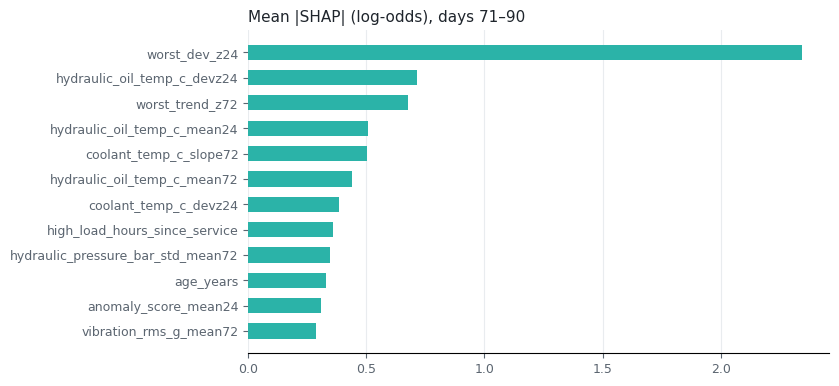

{'worst_dev_z24': 2.3429999351501465,
 'hydraulic_oil_temp_c_devz24': 0.7129999995231628,
 'worst_trend_z72': 0.6779999732971191,
 'hydraulic_oil_temp_c_mean24': 0.5080000162124634,
 'coolant_temp_c_slope72': 0.5019999742507935,
 'hydraulic_oil_temp_c_mean72': 0.4390000104904175,
 'coolant_temp_c_devz24': 0.3840000033378601,
 'high_load_hours_since_service': 0.3580000102519989,
 'hydraulic_pressure_bar_std_mean72': 0.34700000286102295,
 'age_years': 0.33000001311302185,
 'anomaly_score_mean24': 0.3070000112056732,
 'vibration_rms_g_mean72': 0.28700000047683716}

In [14]:
TEAL, VIOLET, INK, MUTED, GRID = "#2BB3A8", "#9B7BE0", "#1F252C", "#5B6570", "#D5DAE0"
hold = (d.split != "train").to_numpy()
sv = M.shap_values(dd.loc[hold, M.FEATURE_COLUMNS].astype(float), model)[:, :-1]
imp = pd.Series(np.abs(sv).mean(0), M.FEATURE_COLUMNS).sort_values(ascending=False)
top = imp.head(12)[::-1]
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.barh(top.index, top.values, color=TEAL, height=0.6)
ax.set_title("Mean |SHAP| (log-odds), days 71–90", loc="left", color=INK, fontsize=11)
for s_ in ["top", "right", "left"]: ax.spines[s_].set_visible(False)
ax.tick_params(colors=MUTED, labelsize=9); ax.grid(axis="x", color=GRID, alpha=0.5); ax.set_axisbelow(True)
fig.savefig(ART / "shap_importance.png", dpi=150, bbox_inches="tight", facecolor="white"); plt.show()
imp.head(12).round(3).to_dict()

## 10 — Lead time per held-out failure (CV), v1 vs v2

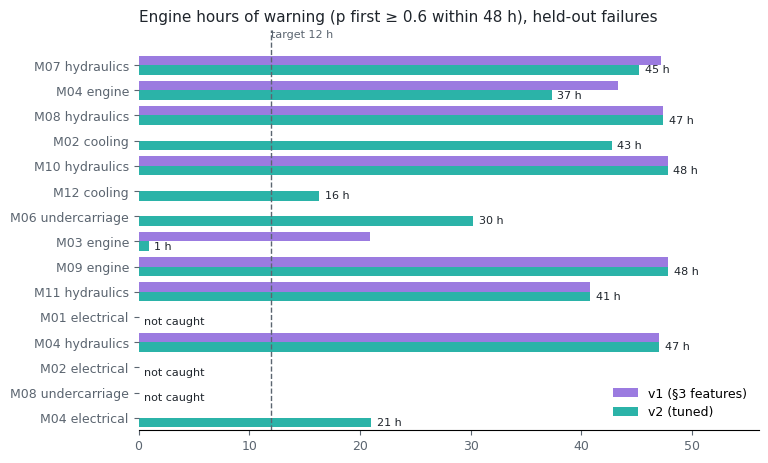

In [15]:
a, b = pfs["xgb_v1"].set_index("failure_ts"), pfs["xgb_v2"].set_index("failure_ts")
lab_ = [f"{r.machine_id} {r.component}" for r in b.itertuples()]
y = np.arange(len(b)); h = 0.38
fig, ax = plt.subplots(figsize=(8, 5.2))
ax.barh(y - h / 2, a.lead_h, height=h, color=VIOLET, label="v1 (§3 features)")
ax.barh(y + h / 2, b.lead_h, height=h, color=TEAL, label="v2 (tuned)")
for yy, v in zip(y + h / 2, b.lead_h):
    ax.text(v + 0.5, yy, "not caught" if v == 0 else f"{v:.0f} h", va="center", fontsize=8, color=INK)
ax.axvline(TARGET_LEAD_H, color=MUTED, ls="--", lw=1); ax.text(TARGET_LEAD_H, -1.1, "target 12 h", fontsize=8, color=MUTED)
ax.set_yticks(y, lab_, color=INK, fontsize=9); ax.set_ylim(len(b) - 0.5, -1.4); ax.set_xlim(0, 56)
ax.set_title("Engine hours of warning (p first ≥ 0.6 within 48 h), held-out failures", loc="left", color=INK, fontsize=11)
for s_ in ["top", "right", "left"]: ax.spines[s_].set_visible(False)
ax.tick_params(colors=MUTED, labelsize=9); ax.legend(frameon=False, fontsize=9, loc="lower right")
fig.savefig(ART / "lead_time.png", dpi=150, bbox_inches="tight", facecolor="white"); plt.show()

## 11 — Save artifacts

In [16]:
cv = res["xgb_v2"]
targets = {"recall_at_0.5_ge_0.75": cv["recall_at_0.5"] >= TARGET_RECALL,
           "median_lead_h_ge_12": cv["median_lead_h"] >= TARGET_LEAD_H}
joblib.dump(model, ART / "xgb_failure.joblib", compress=3)
(ART / "feature_list.json").write_text(json.dumps(M.FEATURE_COLUMNS, indent=2))
config = {"version": "v2", "horizon_engine_h": M.HORIZON_H, "windows_engine_h": list(M.WINDOWS_H),
          "baseline_engine_h": list(M.BASELINE_H), "travel_kmh": M.TRAVEL_KMH, "high_load_pct": M.HIGH_LOAD_PCT,
          "risk_bands": {"low": "< 0.3", "medium": "0.3-0.6", "high": "> 0.6"}, "scales": scales,
          "xgb_params": XGB_PARAMS, "scale_pos_weight": spw, "trained_on_days": [1, 70],
          "component_method": "subsystem with the worst signed z (level deviation or 72 h trend)",
          "subsystem_signals": M.SUBSYSTEM_SIGNALS}
(ART / "config.json").write_text(json.dumps(config, indent=2))
jsonable = lambda o: bool(o) if isinstance(o, np.bool_) else (int(o) if isinstance(o, np.integer) else float(o))
metrics = {
    "model_name": "predictive_maintenance", "version": "v2",
    "versions": {"xgboost": xgboost.__version__, "sklearn": sklearn.__version__, "numpy": np.__version__, "pandas": pd.__version__},
    "label": "failure (maintenance_log) within the next 48 engine hours; failure->repair and censored end hours dropped",
    "split": {"train_days": [1, 70], "val_days": [71, 80], "test_days": [81, 90]},
    "split_counts": split_tab.reset_index().to_dict("records"),
    "test_too_small": "2 failures in days 81-90; main evaluation = grouped time-based CV by failure",
    "cv": {"method": "forward-chaining, boundaries on days with no open 48 h pre-failure window, 48 engine h purge",
           "boundaries": [str(b.date()) for b in BOUNDS[:3]], "folds": fold_tab.reset_index().to_dict("records"),
           "results": res, "per_failure": {k: v.assign(failure_ts=v.failure_ts.astype(str)).round(3).to_dict("records") for k, v in pfs.items()}},
    "component": {"accuracy": comp_acc, "per_component": comp_per},
    "spec_split": spec_res, "targets": {"recall_at_0.5": TARGET_RECALL, "median_lead_h": TARGET_LEAD_H, "met": targets},
    "tuning_round": ["machine-relative 24 h deviation z per signal (baseline t-336..t-72 engine h)",
                     "worst_dev_z24 and worst_trend_z72 across signals", "vibration while travelling (> 2 km/h)"],
    "shap_top": imp.head(10).round(4).to_dict(),
}
(ART / "metrics.json").write_text(json.dumps(metrics, indent=2, default=jsonable))
print(targets)

{'recall_at_0.5_ge_0.75': False, 'median_lead_h_ge_12': True}


## 12 — Parity: `predict_failure` = batch scoring, and the output contract

In [17]:
import importlib; importlib.reload(M); M.load_artifacts.cache_clear()
rng = np.random.default_rng(RANDOM_STATE)
idx = rng.choice(np.flatnonzero(hold), 40, replace=False)
live = M.predict_failure(d.loc[idx, [*M.KEY_COLUMNS, *M.SPEC_FEATURES, *M.RAW_EXTRA_COLUMNS]])
bad = sum(abs(o["failure_probability"] - round(float(p_all[i]), 3)) > 1e-3 for o, i in zip(live, idx))
print("mismatches:", bad, "of", len(idx)); assert bad == 0
one = M.predict_failure(d.loc[int(d[hold & (p_all > 0.6)].index[0]), [*M.KEY_COLUMNS, *M.SPEC_FEATURES, *M.RAW_EXTRA_COLUMNS]].to_dict())
print(json.dumps(one, indent=2, default=str))

mismatches: 0 of 40
{
  "machine_id": "M01",
  "horizon_hours": 48,
  "failure_probability": 0.996,
  "risk_band": "high",
  "likely_component": "electrical",
  "top_factors": [
    {
      "feature": "worst_dev_z24",
      "shap": 2.898
    },
    {
      "feature": "battery_voltage_mean72",
      "shap": 1.127
    },
    {
      "feature": "worst_trend_z72",
      "shap": 0.769
    }
  ]
}


## 13 — Result sheet

In [18]:
v1, v2, bl = res["xgb_v1"], res["xgb_v2"], res["baseline"]
pc1, pc2 = per_comp(v1), per_comp(v2)
ok = lambda b: "✓" if b else "✗"
pct = lambda v: f"{100 * v:.0f} %"
rowfmt = lambda name, r: (f"| {name} | {r['pr_auc']:.2f} | {r['recall_at_0.5']:.2f} | {r['failure_recall_0.5'] * r['failures']:.0f}/{r['failures']} "
                          f"| {r['median_lead_h']:.0f} h | {r['false_alarms_per_machine_week']:.2f} |")
comp_rows = "\n".join(f"| {c} | {int(pc2.loc[c, 'failures'])} | {pc1.loc[c, 'recall_at_0.5']:.2f} → **{pc2.loc[c, 'recall_at_0.5']:.2f}** "
                      f"| {pc1.loc[c, 'failure_recall_0.5'] * pc1.loc[c, 'failures']:.0f} → **{pc2.loc[c, 'failure_recall_0.5'] * pc2.loc[c, 'failures']:.0f}** "
                      f"| {pc1.loc[c, 'median_lead_h']:.0f} → **{pc2.loc[c, 'median_lead_h']:.0f} h** | {pct(comp_per.get(c, 0))} |"
                      for c in pc2.index)
misses = ", ".join(f"{r.machine_id} {r.component} (max p {r.max_p:.2f})" for r in pfs["xgb_v2"].itertuples() if not r.caught)
t = spec_res["test"]
readme = f'''# Predictive maintenance v2: result sheet

XGBoost (models.md §3 parameters, `scale_pos_weight` = neg/pos) predicting a failure within the next
**48 engine hours**, one row per machine per engine hour. The likely component comes from the subsystem with
the worst signal. Notebook: `ml/04_predictive_maintenance.ipynb`. Inference: `ml/inference/maintenance.py` →
`predict_failure(features)`.

**In plain words:** Across 15 held-out failures, the model warns before {v2['failure_recall_0.5'] * v2['failures']:.0f} of them, with a median
**{v2['median_lead_h']:.0f} engine hours** of warning (target 12 h {ok(targets['median_lead_h_ge_12'])}). It raises
{v2['false_alarms_per_machine_week']:.2f} false alarms per machine-week. **Hour-by-hour recall at 0.5 is {v2['recall_at_0.5']:.2f}, missing the 0.75
target {ok(targets['recall_at_0.5_ge_0.75'])}.** Once it catches a failure, it doesn't stay above 0.5 for all 48 hours:
it rises as the drift builds. Hydraulics and engine are reliable. Electrical and undercarriage are not yet.

![Lead time](lead_time.png)

## Why cross-validation, not the test split
Days 81–90 contain only **2 failures** (M08 undercarriage, M04 electrical), so the spec split can't
support a verdict. Main evaluation: **grouped, time-based, forward-chaining CV by failure**. Fold
boundaries fall on {", ".join(str(b.date()) for b in BOUNDS[:3])}, days with no open pre-failure window, so no failure's hours are
split. Each fold trains only on the past, and rows whose 48 h look-ahead reaches the block are purged.
Result: 3 folds and 15 held-out failures. The first 10 (June) are training-only.

| CV, 15 held-out failures | PR-AUC | Recall @0.5 (hours) | Failures caught @0.5 | Median lead (p ≥ 0.6) | False alarms / machine-week |
|---|---|---|---|---|---|
{rowfmt("Baseline rule (worst 72 h trend z, overdue service)", bl)}
{rowfmt("XGBoost v1 (§3 features)", v1)}
{rowfmt("**XGBoost v2 (ships)**", v2)}

Positive-hour prevalence is {pct(v2['prevalence'])}, which is also the PR-AUC of a random score. Lead time is capped at 48 h, and a failure
that never crosses 0.6 counts as 0.

| Component (v1 → v2) | Failures | Recall @0.5 (hours) | Failures caught | Median lead | Component rule right |
|---|---|---|---|---|---|
{comp_rows}

Missed at 0.5 (v2): {misses}. Engine hour-level recall falls in v2
({pc1.loc['engine', 'recall_at_0.5']:.2f} → {pc2.loc['engine', 'recall_at_0.5']:.2f}, 3 failures, all still caught, but M03 only
{pfs['xgb_v2'].set_index('machine_id').loc['M03', 'lead_h']:.0f} h before): with few examples the trees now split on the cross-signal summaries.

## Diagnosis before tuning (v1), and the one tuning round
v1 caught every hydraulics and engine failure and **no cooling or undercarriage failure, and 1 of 3
electrical**. The signal was there: before the missed electrical failures the battery's 24 h mean was about 25 σ below
that machine's normal level, and before the missed cooling failures coolant was 9–10 °C up. 94 % of positive hours
have drift² ≥ 0.25 (checked against `truth/failures.csv`, diagnosis only). The training folds hold 1–2 failures of
those components and **no undercarriage failure before August**. The trees split on absolute levels of
hydraulic oil temperature and on `machine_type` / `age_years`, which act as machine identity, and none of that
transfers. Undercarriage drift only acts while travelling, and on a wheel loader it doesn't move the 24 h vibration mean.
**Tuning round (parameters unchanged):** each signal's 24 h deviation from the machine's own baseline (engine hours
t−336…t−72) in training-std units; the worst deviation and worst 72 h trend across signals (component-agnostic);
vibration while travelling. Failures caught went from {v1['failure_recall_0.5'] * 15:.0f} to {v2['failure_recall_0.5'] * 15:.0f}, and median lead
from {v1['median_lead_h']:.0f} h to {v2['median_lead_h']:.0f} h.

**What still misses and why:** electrical and undercarriage have 1–2 training examples per fold. The battery deviation is
now a feature, but the model still weighs it weakly. The fix is more failure history (or a rule floor, e.g. "any signal
≥ 6 σ worse than baseline → at least medium"). Not done: one tuning round only.

## Shipped model on the spec split (trained on days 1–70)
Test (days 81–90): PR-AUC {t['pr_auc']:.2f}, recall @0.5 {t['recall_at_0.5']:.2f}, {t['failure_recall_0.5'] * t['failures']:.0f}/{t['failures']} failures caught,
median lead {t['median_lead_h']:.0f} h, {t['false_alarms_per_machine_week']:.2f} false alarms / machine-week (2 failures: anecdotal).

![SHAP](shap_importance.png)

## Method notes
- Hourly rows = engine-hour bins with telemetry. The prediction is made at the bin's last minute, and every window trails it.
  Engine hours are rebuilt from `shifts`, cut at `maintenance_log` failures and anchored to `machines.total_engine_hours`
  (matches the logged failure engine hours within 0.05 h).
- §3 features: 24/72 h mean and slope (per engine hour) of coolant, oil pressure, hydraulic oil temperature, hourly
  hydraulic pressure std, vibration and battery (sensor glitches replaced first). Anomaly count (model-1
  `machine_fault` events) and mean score over 24 h. Fault-code episodes over 24 h / 7 calendar days. Hours since service,
  service ratio, high-load (> 80 %) hours since service, machine type one-hot, age.
- Label from `maintenance_log` only. Hours between a failure and its repair are dropped, and so are the last 48 engine
  hours of each machine without a failure ahead (censored).
- Likely component = subsystem with the worst signed z (deviation or 72 h trend). Engine = oil pressure + vibration,
  cooling = coolant, hydraulics = oil temperature + pressure std, electrical = battery, undercarriage = travelling
  vibration beyond the overall vibration change. {pct(comp_acc['all_48h'])} of held-out pre-failure hours right ({pct(comp_acc['last_12h'])} in the last 12 h).
- `top_factors` = XGBoost's exact TreeSHAP (`pred_contribs`, log-odds): the largest contributions pushing the probability up.
- Never read: `anomaly_label`, `anomaly_type`, `data/output/truth/` (except the one diagnosis cell above).
- Artifacts: `xgb_failure.joblib` (compress=3), `config.json` (z-scales, params), `feature_list.json`, `metrics.json`,
  `shap_importance.png`, `lead_time.png`. xgboost pinned in `ml/requirements.txt`. Not yet logged to `model_runs`.
'''
(ART / "README.md").write_text(readme, encoding="utf-8")
sizes = {p.name: p.stat().st_size for p in ART.iterdir()}
print(f"total {sum(sizes.values()) / 1e6:.2f} MB", sizes)

total 0.38 MB {'config.json': 8052, 'feature_list.json': 1424, 'lead_time.png': 79679, 'metrics.json': 25211, 'README.md': 6354, 'shap_importance.png': 60864, 'xgb_failure.joblib': 195688}
